In [1]:
print('test test')

test test


In [2]:
import pandas as pd
import xlrd

file = pd.read_excel('AmesHousing.xlsx')
print(file)

        ID  SalePrice Garage  Overall Qual  Gr Liv Area  Total Bsmt SF  \
0        1     215000    yes             6         1656         1080.0   
1        2     105000    yes             5          896          882.0   
2        3     172000    yes             6         1329         1329.0   
3        4     244000    yes             7         2110         2110.0   
4        5     189900    yes             5         1629          928.0   
...    ...        ...    ...           ...          ...            ...   
2925  2926     142500    yes             6         1003         1003.0   
2926  2927     131000    yes             5          902          864.0   
2927  2928     132000     no             5          970          912.0   
2928  2929     170000    yes             5         1389         1389.0   
2929  2930     188000    yes             7         2000          996.0   

      Lot Area  Year Built  Full Bath  Bedroom AbvGr Neighborhood House Style  
0        31770        1960     

In [3]:
#avq quality per neighbourhood
df = pd.read_excel('AmesHousing.xlsx')

# Group by 'Neighborhood' and calculate the mean for both columns simultaneously
res = df.groupby('Neighborhood')[['Overall Qual', 'SalePrice']].mean()

# Sort by SalePrice (optional, just to keep it organized!)
res = res.sort_values(by='SalePrice', ascending=False)

print(res)

              Overall Qual      SalePrice
Neighborhood                             
NoRidge           7.929577  330319.126761
StoneBr           8.372549  324229.196078
NridgHt           8.277108  322018.265060
GrnHill           7.000000  280000.000000
Veenker           7.208333  248314.583333
Timber            7.194444  246599.541667
Somerst           7.401099  229707.324176
ClearCr           5.977273  208662.090909
Crawfor           6.271845  207550.834951
CollgCr           6.677903  201803.434457
Blmngtn           7.142857  196661.678571
Greens            8.000000  193531.250000
Gilbert           6.515152  190646.575758
NWAmes            6.343511  188406.908397
SawyerW           6.336000  184070.184000
Mitchel           5.543860  162226.631579
NAmes             5.334086  145097.349887
Blueste           6.600000  143590.000000
NPkVill           6.260870  140710.869565
Landmrk           6.000000  137000.000000
Sawyer            5.066225  136751.152318
SWISU             5.437500  135071

In [4]:
df_encoded = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)
print(df_encoded.head())

   ID  SalePrice Garage  Overall Qual  Gr Liv Area  Total Bsmt SF  Lot Area  \
0   1     215000    yes             6         1656         1080.0     31770   
1   2     105000    yes             5          896          882.0     11622   
2   3     172000    yes             6         1329         1329.0     14267   
3   4     244000    yes             7         2110         2110.0     11160   
4   5     189900    yes             5         1629          928.0     13830   

   Year Built  Full Bath  Bedroom AbvGr  ... Neighborhood_NoRidge  \
0        1960          1              3  ...                False   
1        1961          1              2  ...                False   
2        1958          1              3  ...                False   
3        1968          2              3  ...                False   
4        1997          2              3  ...                False   

   Neighborhood_NridgHt  Neighborhood_OldTown  Neighborhood_SWISU  \
0                 False                 F

In [29]:
from sklearn.model_selection import train_test_split
feature_cols = ['Overall Qual', 'Gr Liv Area', 'Year Built', 'Total Bsmt SF'] + [col for col in df_encoded.columns if 'Neighborhood_' in col]

X = df_encoded[feature_cols]
y = df_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Vorm van X_train (features voor training):", X_train.shape)
print("Vorm van y_train (target voor training):", y_train.shape)
print("Vorm van X_test (features voor testen):", X_test.shape)
print("Vorm van y_test (target voor testen):", y_test.shape)

Vorm van X_train (features voor training): (2344, 31)
Vorm van y_train (target voor training): (2344,)
Vorm van X_test (features voor testen): (586, 31)
Vorm van y_test (target voor testen): (586,)


In [30]:
#decision tree
from sklearn.tree import DecisionTreeRegressor
import sklearn.tree._tree

help(DecisionTreeRegressor)

Help on class DecisionTreeRegressor in module sklearn.tree._classes:

class DecisionTreeRegressor(sklearn.base.RegressorMixin, BaseDecisionTree)
 |  DecisionTreeRegressor(
 |      *,
 |      criterion='squared_error',
 |      splitter='best',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=None,
 |      random_state=None,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      ccp_alpha=0.0,
 |      monotonic_cst=None
 |  )
 |
 |  A decision tree regressor.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"squared_error", "friedman_mse", "absolute_error",             "poisson"}, default="squared_error"
 |      The function to measure the quality of a split. Supported criteria
 |      are "squared_error" for the mean squared error, which is equal to
 |      variance reduction as feature selection criterion and minimizes the L2
 | 

In [47]:
model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, min_samples_split=5)
model.fit(X_train, y_train)

print('success')

success


In [48]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Laat het model voorspellingen maken op je onziene testdata
y_pred = model.predict(X_test)

# 2 & 3. Evalueer de voorspellingen met sklearn en numpy

# Mean Absolute Error (MAE): Gemiddelde afwijking in de originele eenheden
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error (MSE): Straft grotere fouten zwaarder af
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE): De wortel van MSE. Vaak de favoriete metric!
# Hier gebruik je Numpy (np.sqrt) samen met sklearn.
rmse = np.sqrt(mse) 

# R-kwadraat (R2): Een score van 0 tot 1 (hoe dichter bij 1, hoe beter je model de variantie verklaart)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

MAE:  21824.49
RMSE: 33500.85
R2:   0.86


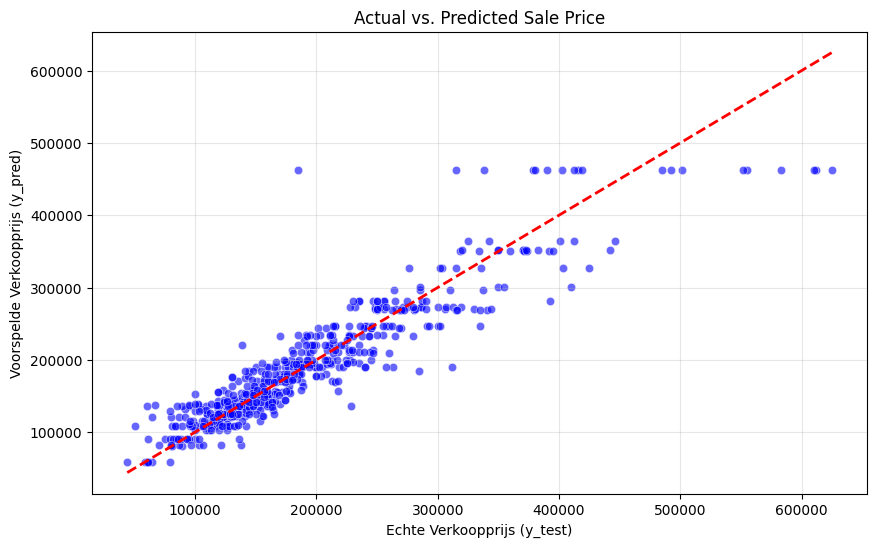

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Actual vs Predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="blue")

# Add a diagonal red line indicating "Perfect Predictions"
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2)

plt.xlabel('Echte Verkoopprijs (y_test)')
plt.ylabel('Voorspelde Verkoopprijs (y_pred)')
plt.title('Actual vs. Predicted Sale Price')
plt.grid(True, alpha=0.3)
plt.show()

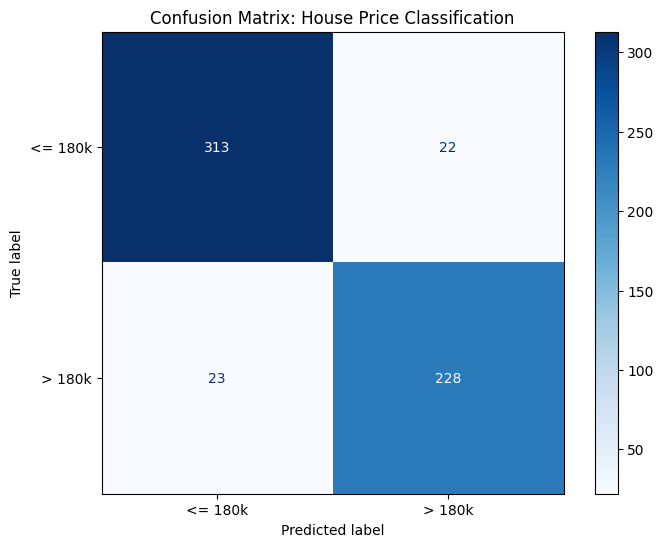

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Convert your continuous target into discrete classes 
# (Let's say everything > $180,000 is "Expensive" (1), else "Normal/Cheap" (0))
y_train_class = (y_train > 180000).astype(int)
y_test_class = (y_test > 180000).astype(int)

# 2. Train a Classifier (NOT a Regressor)
clf_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10)
clf_model.fit(X_train, y_train_class)

# 3. Make categorical predictions
y_pred_class = clf_model.predict(X_test)

# 4. Create and display the Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= 180k', '> 180k'])

# Plot it
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: House Price Classification')
plt.show()